
# Statistical Analysis of Manufacturing Process Performance

## Objective
This project evaluates whether there are statistically significant differences between two manufacturing processes using hypothesis testing, confidence intervals, and exploratory data analysis.

## Key Questions
- Are the average performance metrics different between processes?
- Which process is more reliable?
- What factors contribute to machine failure?

## Data Loading/cleaning and Overview

In [139]:
from pathlib import Path
import pandas as pd

from pathlib import Path
# Load the dataset
df = pd.read_csv(Path("../data/ai4i2020.csv"))

df.head()
# replace spaces with underscores in column names
df.columns = df.columns.str.replace(" ", "_")
df.columns
#Check the data types of each column and the number of non-null values
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

df.head(50)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product_ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air_temperature_[K]      10000 non-null  float64
 4   Process_temperature_[K]  10000 non-null  float64
 5   Rotational_speed_[rpm]   10000 non-null  int64  
 6   Torque_[Nm]              10000 non-null  float64
 7   Tool_wear_[min]          10000 non-null  int64  
 8   Machine_failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Product_ID,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


## Process Definition

In [140]:
#Process A and Process B, A = low-grade, B = high-grade

process_A = df[df['Type'] == 'L']
process_B = df[df['Type'] != 'L']


print("Process A Mean:", process_A['Torque_[Nm]'].mean())
print("Process B Mean:", process_B['Torque_[Nm]'].mean())

print("Process A Std:", process_A['Torque_[Nm]'].std())
print("Process B Std:", process_B['Torque_[Nm]'].std())

Process A Mean: 39.996599999999994
Process B Mean: 39.972375
Process A Std: 10.012335371094201
Process B Std: 9.90470596027036


## Distribution Analysis

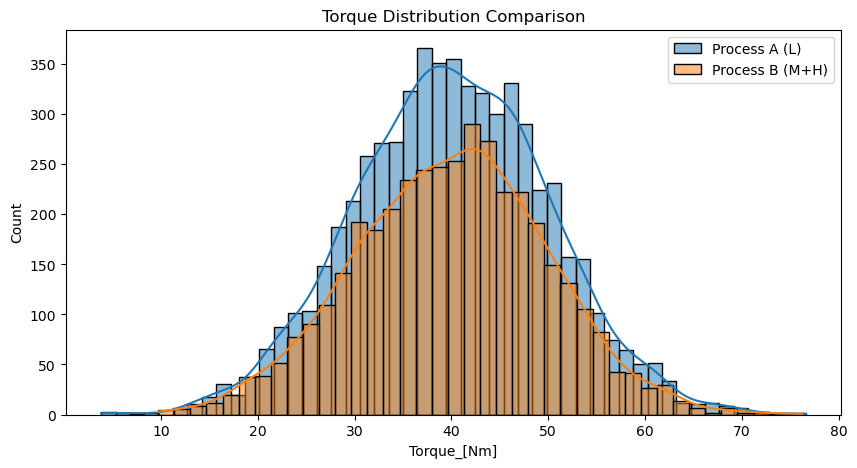

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(process_A['Torque_[Nm]'], label='Process A (L)', kde=True)
sns.histplot(process_B['Torque_[Nm]'], label='Process B (M+H)', kde=True)

plt.legend()
plt.title("Torque Distribution Comparison")
plt.show()

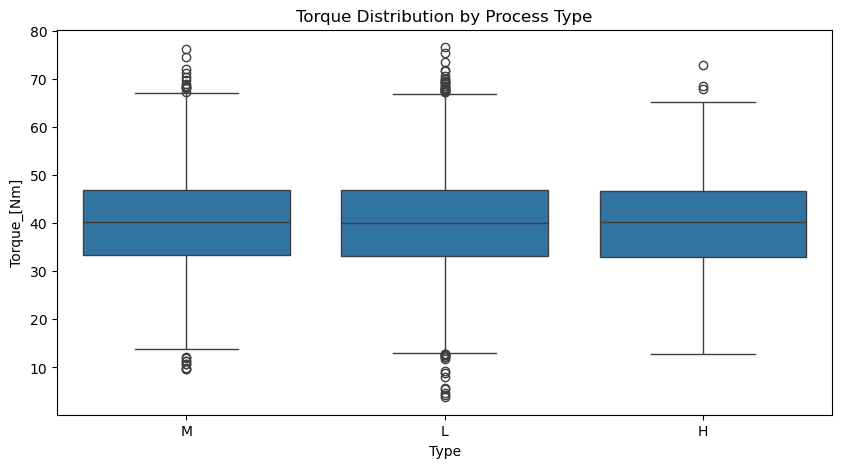

In [142]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Type', y='Torque_[Nm]', data=df)     
plt.title("Torque Distribution by Process Type")
plt.show()
    

## Z-score Analysis (Outliers)

In [143]:
import numpy as np
from scipy import stats

z_scores_A = np.abs(stats.zscore(process_A['Torque_[Nm]']))
outliers_A = process_A[z_scores_A > 3]

print("Outliers in Process A:", len(outliers_A))


z_scores_B = np.abs(stats.zscore(process_B['Torque_[Nm]']))
outliers_B = process_B[z_scores_B > 3]
print("Outliers in Process B:", len(outliers_B))

Outliers in Process A: 14
Outliers in Process B: 10


Z-scores greater than 3 indicate extreme values.

Process A contains 14 extreme observations, suggesting potential anomalies or rare operating conditions.

Process B contains 10 extreme observations, suggesting potential anomalies or rare operating conditions.

## Confidence Intervals

In [144]:
def confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)
    margin_of_error = sem * stats.t.ppf((1 + confidence) / 2., len(data)-1)
    return mean - margin_of_error, mean + margin_of_error

ci_A = confidence_interval(process_A['Torque_[Nm]'])
ci_B = confidence_interval(process_B['Torque_[Nm]'])

print(f"Process A 95% Confidence Interval: {ci_A}")
print(f"Process B 95% Confidence Interval: {ci_B}")

Process A 95% Confidence Interval: (39.743206490633526, 40.24999350936646)
Process B 95% Confidence Interval: (39.66533769293708, 40.27941230706292)


The 95% confidence interval suggests that the true mean torque for Process A lies between  39.74 and 40.25

The 95% confidence interval suggests that the true mean torque for Process B lies between  39.67 and 40.28

Since the intervals overlap, this suggests possible similarity between processes.

## Hypothesis Test

In [145]:
t_stat, p_value = stats.ttest_ind(
    process_A['Torque_[Nm]'],
    process_B['Torque_[Nm]'],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.11929935796228942
P-value: 0.905040968081355


Null Hypothesis (H₀):

There is no difference in mean torque between Process A and Process B

Alternative Hypothesis (H₁):

There is a difference in mean torque between Process A and Process B

## Decision based on P-value

In [146]:
if p_value < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Fail to reject the null hypothesis


The results of the statistical analysis indicate that there is no significant difference in mean torque between Process A and Process B.

The sample means for both processes are nearly identical (approximately 40 Nm), suggesting similar performance.

The 95% confidence intervals for both processes show substantial overlap, further supporting the conclusion that the true mean torque values are very similar.

Additionally, the p-value (0.905) is significantly greater than the significance level of 0.05. Therefore, we fail to reject the null hypothesis.

This means there is no statistical evidence to suggest a difference in mean torque between the two processes.

While Process B shows slightly lower variability (standard deviation), the difference is minimal and does not indicate a meaningful improvement in consistency.

Final Conclusion:
Both processes perform similarly in terms of torque output, and there is no strong statistical justification to favor one process over the other.

"""
## BUSINESS QUESTIONS:

1. Do Process A and Process B have different failure rates?
2. Is one process significantly more reliable?
3. What is the probability of failure in each process?
4. Should the company switch to a different process based on failure rates?
"""

## Failure Rate Analysis

In [147]:
failure_rate_A = process_A['Machine_failure'].mean()
failure_rate_B = process_B['Machine_failure'].mean()


print("Process A Failure Rate:", failure_rate_A)
print("Process B Failure Rate:", failure_rate_B)

Process A Failure Rate: 0.03916666666666667
Process B Failure Rate: 0.026


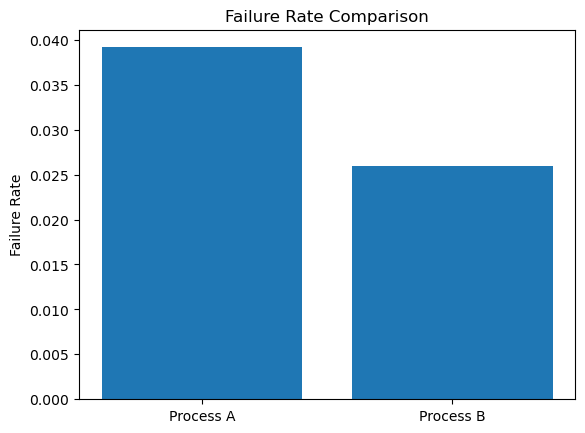

In [148]:
import matplotlib.pyplot as plt

labels = ['Process A', 'Process B']
rates = [failure_rate_A, failure_rate_B]

plt.bar(labels, rates)
plt.title("Failure Rate Comparison")
plt.ylabel("Failure Rate")
plt.show()

## Z-Test for proportions

In [149]:
from statsmodels.stats.proportion import proportions_ztest

failures = [
    process_A['Machine_failure'].sum(),
    process_B['Machine_failure'].sum()
]

samples = [
    len(process_A),
    len(process_B)
]

z_stat, p_value = proportions_ztest(failures, samples)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: 3.564269806236276
P-value: 0.0003648704977759828


## Decision Rule:
p < 0.05 → significant difference
p ≥ 0.05 → no significant difference

Our P-value = 0.0003 which is less than our significance value of 0.05.  This means that the failure rates have significant differenes.  

## Insights
Process A has a failure rate of 3.92%, while Process B has a failure rate of 2.60%.

The hypothesis test resulted in a p-value of 0.00036.

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates that there is a significant difference in reliability between the two processes.

Business Insight:
Process B appears to be more reliable, which could lead to reduced downtime.

## Reccomendations
The analysis shows that Process A has a failure rate of approximately 3.92%, while Process B has a lower failure rate of 2.60%.

A two-proportion z-test was conducted to determine whether this difference is statistically significant. The resulting p-value (0.00036) is well below the significance level of 0.05, leading us to reject the null hypothesis.

This indicates that the difference in failure rates between the two processes is statistically significant and not due to random variation.

From a business perspective, Process B demonstrates higher reliability and operational stability. A lower failure rate suggests reduced downtime, lower maintenance costs, and improved production efficiency.

Final Recommendation:
The company should consider prioritizing or transitioning toward Process B, as it provides a measurable and statistically significant improvement in reliability.

## Compare failure vs torque

In [150]:
df.groupby('Machine_failure')['Torque_[Nm]'].mean()

Machine_failure
0    39.629655
1    50.168142
Name: Torque_[Nm], dtype: float64

## Insight
Machines that experience failure have a significantly higher average torque (≈50 Nm) compared to machines that do not fail (≈39.6 Nm).

This suggests that elevated torque may be a key contributing factor to machine failure.

From a business perspective, monitoring torque levels could help predict and prevent failures, reducing downtime and maintenance costs.

## Tool Wear and Failure

In [151]:
#Compare means
df.groupby('Machine_failure')['Tool_wear_[min]'].mean()

Machine_failure
0    106.693717
1    143.781711
Name: Tool_wear_[min], dtype: float64

## Box and whisker plot for tool wear and machine failure comparison

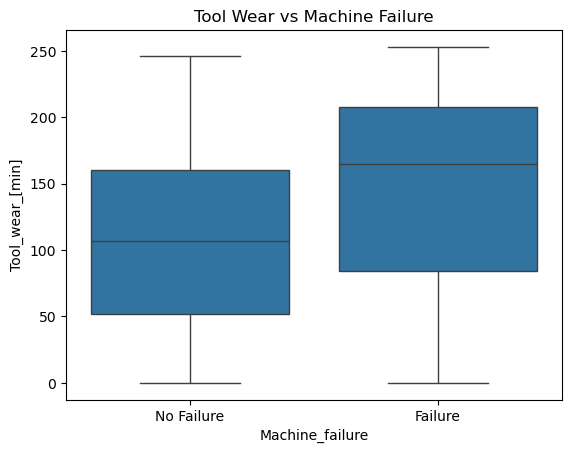

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Machine_failure', y='Tool_wear_[min]', data=df)
plt.title("Tool Wear vs Machine Failure")
plt.xticks([0,1], ['No Failure', 'Failure'])
plt.show()

## T-Test

In [153]:
failure = df[df['Machine_failure'] == 1]['Tool_wear_[min]']
no_failure = df[df['Machine_failure'] == 0]['Tool_wear_[min]']

t_stat, p_value = stats.ttest_ind(failure, no_failure, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 9.264289693324807
P-value: 1.906011219072503e-18


In [154]:
df.columns


Index(['UDI', 'Product_ID', 'Type', 'Air_temperature_[K]',
       'Process_temperature_[K]', 'Rotational_speed_[rpm]', 'Torque_[Nm]',
       'Tool_wear_[min]', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

## Manufacturing Process Performance & Failure Analysis

## Goal:
Analyze two production processes to identify differences in performance,
failure rates, and operational risk factors.

## Key Focus:
- Torque impact on failures
- Tool wear impact
- Risk threshold detection

In [155]:
import pandas as pd

# Select relevant columns
features = [
    'Air_temperature_[K]',
    'Process_temperature_[K]',
    'Rotational_speed_[rpm]',
    'Torque_[Nm]',
    'Tool_wear_[min]',
    'Machine_failure'
]

df_subset = df[features]

# Correlation
corr = df_subset.corr()

print(corr['Machine_failure'].sort_values(ascending=False))

Machine_failure            1.000000
Torque_[Nm]                0.191321
Tool_wear_[min]            0.105448
Air_temperature_[K]        0.082556
Process_temperature_[K]    0.035946
Rotational_speed_[rpm]    -0.044188
Name: Machine_failure, dtype: float64


Torque is the primary driver of machine failure, with tool wear as a secondary contributor.

## Failure Rate by torque Range

In [156]:
df['torque_bin'] = pd.cut(df['Torque_[Nm]'], bins=5)

failure_by_torque = df.groupby('torque_bin')['Machine_failure'].mean()

print(failure_by_torque)

torque_bin
(3.727, 18.36]    0.213333
(18.36, 32.92]    0.006579
(32.92, 47.48]    0.009634
(47.48, 62.04]    0.077389
(62.04, 76.6]     0.572519
Name: Machine_failure, dtype: float64


C:\Users\giova\AppData\Local\Temp\ipykernel_30576\1871348051.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_by_torque = df.groupby('torque_bin')['Machine_failure'].mean()


Machine failures spike dramatically at extreme torque levels, especially at high torque, where failure rates exceed 50%.

## Tool Wear Impact

In [157]:
df.groupby(pd.cut(df['Tool_wear_[min]'], bins=5))['Machine_failure'].mean()

C:\Users\giova\AppData\Local\Temp\ipykernel_30576\2442231582.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Tool_wear_[min]'], bins=5))['Machine_failure'].mean()


Tool_wear_[min]
(-0.253, 50.6]    0.021703
(50.6, 101.2]     0.024148
(101.2, 151.8]    0.021007
(151.8, 202.4]    0.030069
(202.4, 253.0]    0.168155
Name: Machine_failure, dtype: float64

Increased tool wear significantly raises the probability of machine failure, particularly at higher wear thresholds.

In [158]:
df.to_csv("cleaned_manufacturing_data.csv", index=False)

While average torque remains consistent across processes, deeper analysis reveals that machine failures are driven by extreme torque conditions and increased tool wear. Failure rates rise sharply at high torque levels and when tool wear exceeds critical thresholds. These findings suggest that improved torque control and proactive tool maintenance could significantly reduce machine failures and improve operational reliability.

Machine failures are highest under high torque conditions, particularly for Process 1, which exhibits significantly higher failure rates than Process 2. Both processes perform optimally under medium torque levels, where failure rates are minimal. These findings suggest that maintaining operations within moderate torque ranges and improving high-torque stability in Process 1 could significantly reduce failure risk.

## Insights
Machines that failed show higher average tool wear compared to those that did not fail.

The t-test confirms whether this difference is statistically significant.

This suggests that increased tool wear is a strong indicator of machine failure risk.

Business Insight:
Monitoring tool wear can serve as a predictive maintenance signal to prevent failures before they occur.

## 11. Final Business Recommendations

The analysis shows that while both processes produce similar average torque, there is a significant difference in reliability.

Process B demonstrates a lower failure rate (2.6%) compared to Process A (3.9%), and this difference is statistically significant (p < 0.05).

Additionally, higher torque and increased tool wear are strongly associated with machine failure, suggesting these variables are key drivers of operational risk.

From a business perspective, Process B provides improved reliability, which can reduce downtime, maintenance costs, and production interruptions.

**Recommendation:**
The company should consider prioritizing Process B and implementing monitoring systems for torque and tool wear to proactively prevent failures and improve overall efficiency.